# Drawing variability across sites (for 201b)

Pipeline starting from stored CLIP embedding docs.

**Outputs:**
- `data/distance_cat_site.csv` — per-drawing cosine distance to category × site centroid (input for R mixed-effects models, Analysis 3)
- `data/category_divergence.csv` — mean cross-site category divergence (Analysis 2)

RDM results (Analysis 1) are printed in-notebook.


In [1]:
from pathlib import Path
import re, os
from itertools import combinations

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from scipy.stats import spearmanr

from vislearnlabpy.embeddings.embedding_store import EmbeddingStore
from vislearnlabpy.embeddings.similarity_utils import cosine_sim, cosine_matrix


/opt/miniconda3/envs/vislearnlabpy/lib/python3.12/site-packages/pydantic/_migration.py:283: UserWarning: `pydantic.error_wrappers:ValidationError` has been moved to `pydantic:ValidationError`.
  warnings.warn(f'`{import_path}` has been moved to `{new_location}`.')


In [2]:
embedding_dir = Path("../data/embeddings")

beijing_store  = EmbeddingStore.from_doc(str(embedding_dir / "beijing_store"))
kisumu_store   = EmbeddingStore.from_doc(str(embedding_dir / "kisumu_store"))
sanjose_store  = EmbeddingStore.from_doc(str(embedding_dir / "sanjose_store"))
newdelhi_store = EmbeddingStore.from_doc(str(embedding_dir / "newdelhi_store"))


/opt/miniconda3/envs/vislearnlabpy/lib/python3.12/site-packages/rich/live.py:256: UserWarning: install "ipywidgets"
for Jupyter support
  warnings.warn('install "ipywidgets" for Jupyter support')

In [3]:
text_store = EmbeddingStore.from_doc(str(embedding_dir / "text_embeddings"))
text_embs = {}
for emb in text_store.EmbeddingList:
    label = emb.text.lower().strip()
    text_embs[label] = np.array(emb.embedding)

print(list(text_embs.keys()))

['drawing of a airplane', 'drawing of a bike', 'drawing of a bird', 'drawing of a car', 'drawing of a cat', 'drawing of a chair', 'drawing of a cup', 'drawing of a hat', 'drawing of a house', 'drawing of a rabbit', 'drawing of a tree', 'drawing of a watch']


## Build drawing-level dataframe

Each embedding store has `.text` (drawing category) and `.url` (original file path). Age and participant_id are parsed from the URL. India age is looked up from the existing recognizability CSV.


In [4]:
CATEGORIES = [
    "airplane", "bike", "bird", "car", "cat", "chair",
    "cup", "hat", "house", "rabbit", "tree", "watch"
]

CATEGORIES_GROUPED = [
    # big objects
    "airplane", "bike", "car", "chair", "house", "tree",
    # small objects
    "cup", "hat", "watch",
    # animals
    "bird", "cat", "rabbit",
]

# metadata parsers 
# URL format differs by site, yikes

def parse_beijing_url(url):
    fn = os.path.basename(url)
    age = int(re.search(r'age(\d+)', fn).group(1))
    location = "Beijing" if "THU" in fn else "USA"
    participant_id = fn.removesuffix('.png').split('_')[-1]
    return {'location': location, 'age': age, 'participant_id': participant_id}

def parse_kisumu_url(url):
    fn = os.path.basename(url)
    # age in filename is offset by 3 years
    age = int(re.search(r'age(\d+)', fn).group(1)) + 3
    participant_id = fn.split('_')[0]
    return {'location': 'Kisumu', 'age': age, 'participant_id': participant_id}

def parse_india_url(url, age_lookup):
    fn = os.path.basename(url)
    for prefix in ('a_', 'an_', 'three_', 'two_'):
        if fn.startswith(prefix):
            fn = fn[len(prefix):]
            break
    parts = fn.split('_')
    participant_id = parts[2].upper()
    return {'location': 'India', 'age': age_lookup.get(participant_id, np.nan), 'participant_id': participant_id}

# new dehli age lookup from existing CSV
_meta = pd.read_csv("../data/clip_recognizability.csv")
india_age_lookup = (
    _meta[_meta['location'] == 'India']
    .drop_duplicates('participant_id')
    .set_index('participant_id')['age']
    .to_dict()
)

# per-site dataframes from stores
def build_store_df(store, parse_fn, **kwargs):
    rows = []
    for emb in store.EmbeddingList:
        if emb.text not in CATEGORIES:
            continue
        meta = parse_fn(emb.url, **kwargs)
        rows.append({'embedding': np.array(emb.embedding), 'drawing_category': emb.text, **meta})
    return pd.DataFrame(rows)

emb_df = pd.concat([
    build_store_df(beijing_store,  parse_beijing_url),
    build_store_df(sanjose_store,  parse_beijing_url),   # same URL format as Beijing
    build_store_df(kisumu_store,   parse_kisumu_url),
    build_store_df(newdelhi_store, parse_india_url, age_lookup=india_age_lookup),
], ignore_index=True)

emb_df = emb_df[(emb_df['age'] >= 4) & (emb_df['age'] <= 9)].reset_index(drop=True)
print(emb_df.groupby('location').size())
print(f"Total: {len(emb_df)} drawings")


location
Beijing     724
India      1507
Kisumu     1440
USA         716
dtype: int64
Total: 4387 drawings


## Category x site centroids `distance_cat_site.csv`

Centroid = mean embedding over all ages per (location, drawing_category).

In [5]:
emb_df['location'] = emb_df['location'].replace({'USA': 'San Jose', 'India': 'New Delhi'})

# compute centroids (location x category, all ages pooled)
centroids = {
    (loc, cat): np.mean(np.stack(grp['embedding'].values), axis=0)
    for (loc, cat), grp in emb_df.groupby(['location', 'drawing_category'])
}

# cosine distance from each drawing to its category-site centroid
distances = [
    1 - float(cosine_sim(row['embedding'], centroids[(row['location'], row['drawing_category'])]))
    for _, row in emb_df.iterrows()
]
emb_df['distance_cat_site'] = distances

# emb_df[['location', 'age', 'participant_id', 'drawing_category', 'distance_cat_site']].to_csv(
#     "../data/distance_cat_site.csv", index=False
# )
print(emb_df['distance_cat_site'].describe())


count    4387.000000
mean        0.058226
std         0.022614
min         0.016602
25%         0.042480
50%         0.054199
75%         0.069824
max         0.252441
Name: distance_cat_site, dtype: float64


### CLIP recognizability

In [6]:
text_labels = list(text_embs.keys())
text_matrix = np.stack([text_embs[l] for l in text_labels])

def classify_drawing(drawing_emb, target_category):
    sims = cosine_matrix(drawing_emb.reshape(1, -1), text_matrix)[0]
    predicted = text_labels[np.argmax(sims)]
    target_key = f"drawing of a {target_category}"
    target_sim = sims[text_labels.index(target_key)]
    recognized = predicted == target_key
    return recognized, float(target_sim)

results = emb_df.apply(
    lambda row: classify_drawing(row['embedding'], row['drawing_category']), axis=1
)
emb_df['recognized'] = results.apply(lambda x: x[0])
emb_df['target_similarity'] = results.apply(lambda x: x[1])

In [7]:
# renaming sites
emb_df.drop(columns=['embedding']).to_csv("../data/distance_cat_site.csv", index=False)

## EDA: distance-to-centroid distributions

In [8]:
dist_df = pd.read_csv("../data/distance_cat_site.csv")

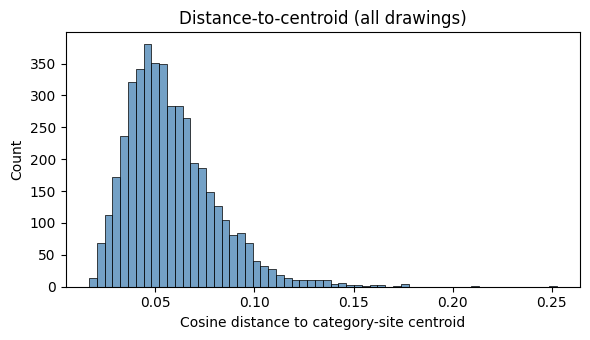

In [9]:
fig, ax = plt.subplots(figsize=(6, 3.5))
sns.histplot(dist_df['distance_cat_site'], bins=60, ax=ax, color='steelblue')
ax.set(xlabel='Cosine distance to category-site centroid', ylabel='Count',
       title='Distance-to-centroid (all drawings)')
plt.tight_layout()
plt.savefig("../data/figures/eda_plots/dist_overall.png", dpi=150)
plt.show()

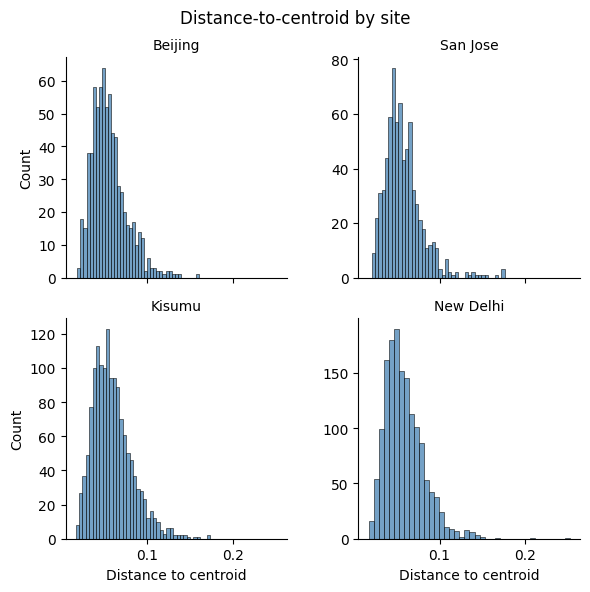

In [10]:
g = sns.FacetGrid(dist_df, col='location', col_wrap=2, height=3, sharex=True, sharey=False)
g.map(sns.histplot, 'distance_cat_site', bins=40, color='steelblue')
g.set_axis_labels('Distance to centroid', 'Count')
g.set_titles(col_template='{col_name}')
g.figure.subplots_adjust(top=0.9)
g.figure.suptitle('Distance-to-centroid by site')
plt.savefig("../data/figures/eda_plots/dist_by_site.png", dpi=150)
plt.show()

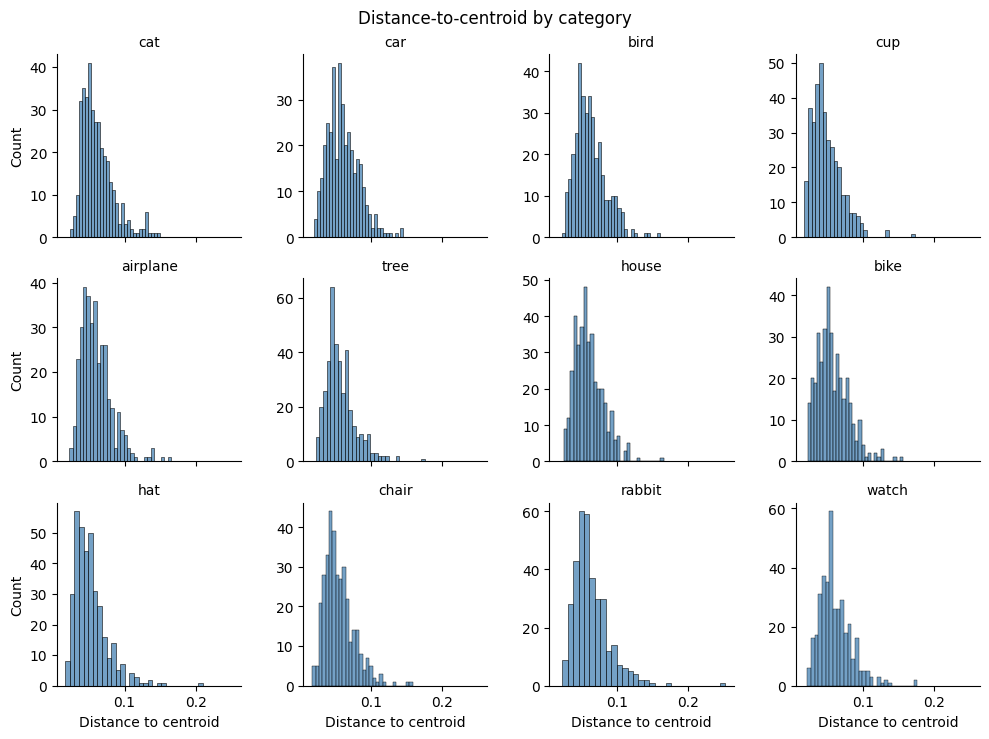

In [11]:
g = sns.FacetGrid(dist_df, col='drawing_category', col_wrap=4, height=2.5, sharex=True, sharey=False)
g.map(sns.histplot, 'distance_cat_site', bins=30, color='steelblue')
g.set_axis_labels('Distance to centroid', 'Count')
g.set_titles(col_template='{col_name}')
g.figure.subplots_adjust(top=0.92)
g.figure.suptitle('Distance-to-centroid by category')
plt.savefig("../data/figures/eda_plots/dist_by_category.png", dpi=150)
plt.show()

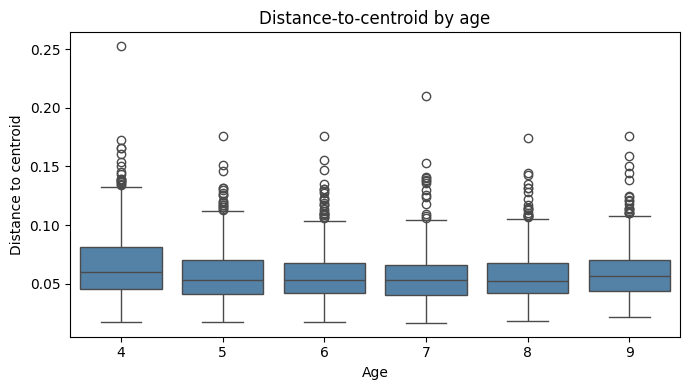

In [12]:
fig, ax = plt.subplots(figsize=(7, 4))
sns.boxplot(data=dist_df, x='age', y='distance_cat_site', color='steelblue', ax=ax)
ax.set(xlabel='Age', ylabel='Distance to centroid',
       title='Distance-to-centroid by age')
plt.tight_layout()
plt.savefig("../data/figures/eda_plots/dist_by_age.png", dpi=150)
plt.show()

In [13]:
from scipy.stats import skew
print(f"Overall skewness: {skew(dist_df['distance_cat_site'].dropna()):.3f}")
for loc, grp in dist_df.groupby('location'):
    print(f"{loc}: skewness = {skew(grp['distance_cat_site'].dropna()):.3f}")

Overall skewness: 1.316
Beijing: skewness = 1.122
Kisumu: skewness = 1.032
New Delhi: skewness = 1.469
San Jose: skewness = 1.675


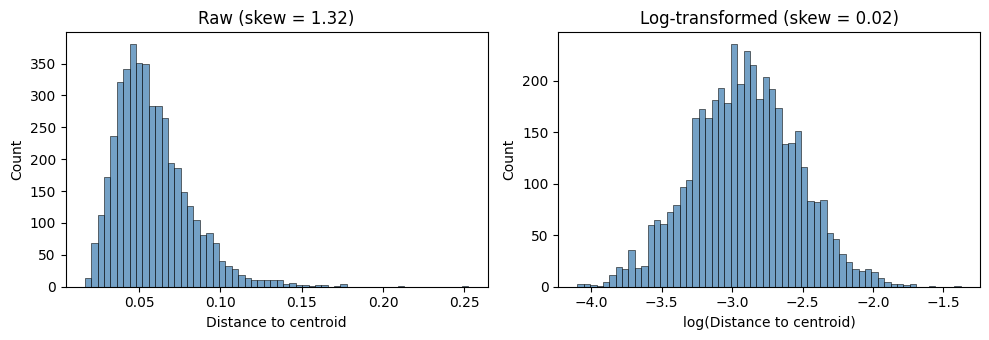

In [14]:
dist_df['log_distance'] = np.log(dist_df['distance_cat_site'])

fig, axes = plt.subplots(1, 2, figsize=(10, 3.5))
sns.histplot(dist_df['distance_cat_site'], bins=60, ax=axes[0], color='steelblue')
axes[0].set(title=f"Raw (skew = {skew(dist_df['distance_cat_site'].dropna()):.2f})",
            xlabel='Distance to centroid')
sns.histplot(dist_df['log_distance'].dropna(), bins=60, ax=axes[1], color='steelblue')
axes[1].set(title=f"Log-transformed (skew = {skew(dist_df['log_distance'].dropna()):.2f})",
            xlabel='log(Distance to centroid)')
plt.tight_layout()
plt.savefig("../data/figures/eda_plots/dist_transform_comparison.png", dpi=150)
plt.show()

In [15]:
dist_df['distance_cat_site'].eq(0).sum()

np.int64(0)

## RDM analysis (Analysis 1)

12×12 category RDMs per site (pairwise cosine distances between mean category embeddings). Spearman-correlated across all 6 site pairs, with bootstrap 95% CIs and two permutation tests.


In [16]:
# helper functions

def compute_rdm(df, categories):
    means = np.stack([
        np.mean(np.stack(df[df['drawing_category'] == cat]['embedding'].values), axis=0)
        if (df['drawing_category'] == cat).any() else np.zeros(512)
        for cat in categories
    ])
    rdm = 1 - cosine_matrix(means, means)
    np.fill_diagonal(rdm, 0)
    return rdm

def rdm_from_embs_dict(embs_dict, categories):
    means = np.stack([
        np.mean(embs_dict[cat], axis=0) if embs_dict.get(cat) else np.zeros(512)
        for cat in categories
    ])
    rdm = 1 - cosine_matrix(means, means)
    np.fill_diagonal(rdm, 0)
    return rdm

def spearman_rdm(rdm1, rdm2):
    tril = np.tril_indices(len(rdm1), k=-1)
    r, _ = spearmanr(rdm1[tril], rdm2[tril])
    return r

def get_embs_by_category(df, categories):
    return {cat: list(np.stack(df[df['drawing_category'] == cat]['embedding'].values))
            for cat in categories if (df['drawing_category'] == cat).any()}


In [17]:
SITE_NAMES = ['Beijing', 'San Jose', 'Kisumu', 'New Delhi']

In [18]:
# compute RDMs + observed correlations
site_rdms = {loc: compute_rdm(emb_df[emb_df['location'] == loc], CATEGORIES_GROUPED) for loc in SITE_NAMES}

obs_corrs = {}
for s1, s2 in combinations(SITE_NAMES, 2):
    r = spearman_rdm(site_rdms[s1], site_rdms[s2])
    obs_corrs[(s1, s2)] = r
    print(f"{s1} vs {s2}: r = {r:.3f}")


Beijing vs San Jose: r = 0.953
Beijing vs Kisumu: r = 0.725
Beijing vs New Delhi: r = 0.820
San Jose vs Kisumu: r = 0.777
San Jose vs New Delhi: r = 0.842
Kisumu vs New Delhi: r = 0.811


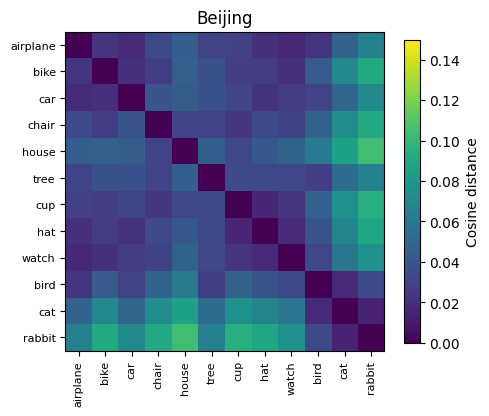

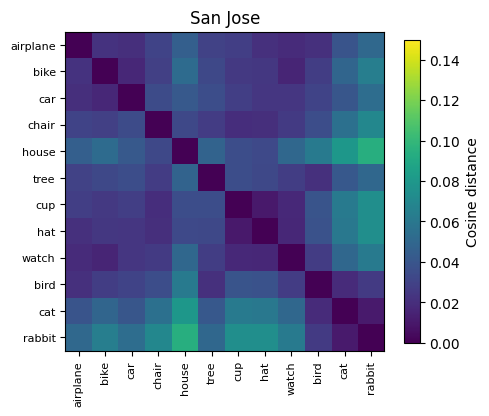

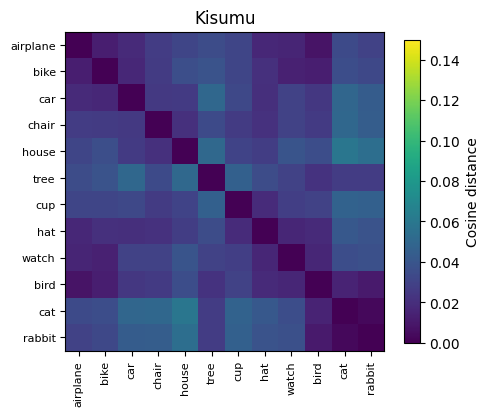

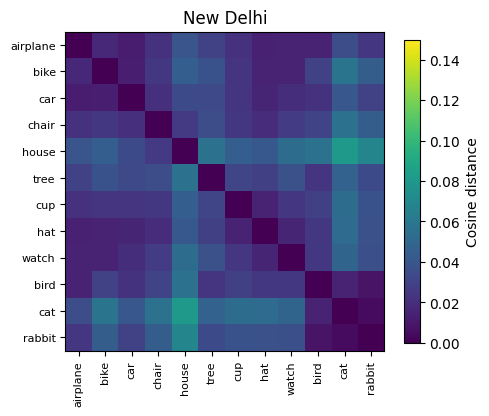

In [19]:
# visualize RDMs per site
for loc in SITE_NAMES:
    fig, ax = plt.subplots(figsize=(5, 4.5))
    im = ax.imshow(site_rdms[loc], cmap='viridis', vmin=0, vmax=0.15)
    ax.set_xticks(range(len(CATEGORIES)))
    ax.set_yticks(range(len(CATEGORIES)))
    ax.set_xticklabels(CATEGORIES_GROUPED, rotation=90, fontsize=8)
    ax.set_yticklabels(CATEGORIES_GROUPED, fontsize=8)
    ax.set_title(loc)
    fig.colorbar(im, ax=ax, shrink=0.8, label='Cosine distance')
    plt.tight_layout()
    plt.savefig(f"../data/figures/rdm_plots/stats/rdm_{loc.lower().replace(" ", "_")}.svg", dpi=150, bbox_inches='tight')
    plt.show()

In [20]:
np.max([rdm[np.tril_indices(12, k=-1)].max() for rdm in site_rdms.values()])

np.float16(0.104)

In [21]:
# bootstrap 95% CIs (N=1000, resample within category × site cells)

def bootstrap_rdm_corrs(emb_df, site_names, categories, n_boot=1000, seed=42):
    rng = np.random.default_rng(seed)
    site_embs = {loc: get_embs_by_category(emb_df[emb_df['location'] == loc], categories)
                 for loc in site_names}
    pairs = list(combinations(site_names, 2))
    boot_corrs = {pair: [] for pair in pairs}
    tril = np.tril_indices(len(categories), k=-1)

    for _ in range(n_boot):
        boot_rdms = {}
        for loc in site_names:
            boot_embs = {}
            for cat in categories:
                embs = site_embs[loc].get(cat, [])
                n = len(embs)
                boot_embs[cat] = [embs[i] for i in rng.integers(0, n, size=n)] if n else []
            boot_rdms[loc] = rdm_from_embs_dict(boot_embs, categories)
        for (s1, s2) in pairs:
            r, _ = spearmanr(boot_rdms[s1][tril], boot_rdms[s2][tril])
            boot_corrs[(s1, s2)].append(r)

    return {pair: np.array(vals) for pair, vals in boot_corrs.items()}

boot_results = bootstrap_rdm_corrs(emb_df, SITE_NAMES, CATEGORIES)

print("Bootstrap 95% CIs:")
for (s1, s2), vals in boot_results.items():
    lo, hi = np.percentile(vals, [2.5, 97.5])
    print(f"{s1} vs {s2}: r = {obs_corrs[(s1,s2)]:.3f}, 95% CI [{lo:.3f}, {hi:.3f}]")


Bootstrap 95% CIs:
Beijing vs San Jose: r = 0.953, 95% CI [0.839, 0.947]
Beijing vs Kisumu: r = 0.725, 95% CI [0.568, 0.789]
Beijing vs New Delhi: r = 0.820, 95% CI [0.692, 0.869]
San Jose vs Kisumu: r = 0.777, 95% CI [0.593, 0.823]
San Jose vs New Delhi: r = 0.842, 95% CI [0.708, 0.883]
Kisumu vs New Delhi: r = 0.811, 95% CI [0.683, 0.865]


In [22]:
# 1a category-label permutation test
# H0: RDM correlation is not specific to category identity (sanity check, expect p \approx 0)

def category_perm_test(rdm1, rdm2, n_perm=1000, seed=42):
    rng = np.random.default_rng(seed)
    tril = np.tril_indices(len(rdm1), k=-1)
    obs_r, _ = spearmanr(rdm1[tril], rdm2[tril])
    perm_rs = np.array([
        spearmanr(rdm1[np.ix_(idx := rng.permutation(len(rdm1)), idx)][tril], rdm2[tril])[0]
        for _ in range(n_perm)
    ])
    return obs_r, perm_rs, float(np.mean(perm_rs >= obs_r))

print("1a — category-label permutation (p = proportion of shuffled \geq observed):")
for (s1, s2) in obs_corrs:
    obs_r, _, p = category_perm_test(site_rdms[s1], site_rdms[s2])
    print(f"{s1} vs {s2}: r = {obs_r:.3f}, p = {p:.4f}")


1a — category-label permutation (p = proportion of shuffled \geq observed):
Beijing vs San Jose: r = 0.953, p = 0.0000
Beijing vs Kisumu: r = 0.725, p = 0.0000


<>:14: SyntaxWarning: invalid escape sequence '\g'
<>:14: SyntaxWarning: invalid escape sequence '\g'
/var/folders/65/x30167d155g8x2p33b_x9s6w0000gp/T/ipykernel_11481/1458434876.py:14: SyntaxWarning: invalid escape sequence '\g'
  print("1a — category-label permutation (p = proportion of shuffled \geq observed):")


Beijing vs New Delhi: r = 0.820, p = 0.0000
San Jose vs Kisumu: r = 0.777, p = 0.0000
San Jose vs New Delhi: r = 0.842, p = 0.0000
Kisumu vs New Delhi: r = 0.811, p = 0.0000


In [23]:
# 1b site-label permutation test
# H0: site boundary is meaningless — any random partition of same sizes gives equally correlated RDMs

def site_perm_test(loc1, loc2, emb_df, categories, n_perm=1000, seed=42):
    rng = np.random.default_rng(seed)
    tril = np.tril_indices(len(categories), k=-1)
    embs1 = get_embs_by_category(emb_df[emb_df['location'] == loc1], categories)
    embs2 = get_embs_by_category(emb_df[emb_df['location'] == loc2], categories)
    obs_r, _ = spearmanr(
        rdm_from_embs_dict(embs1, categories)[tril],
        rdm_from_embs_dict(embs2, categories)[tril]
    )
    perm_rs = []
    for _ in range(n_perm):
        pe1, pe2 = {}, {}
        for cat in categories:
            all_e = embs1.get(cat, []) + embs2.get(cat, [])
            n1 = len(embs1.get(cat, []))
            if all_e:
                idx = rng.permutation(len(all_e))
                pe1[cat] = [all_e[i] for i in idx[:n1]]
                pe2[cat] = [all_e[i] for i in idx[n1:]]
            else:
                pe1[cat] = pe2[cat] = []
        r, _ = spearmanr(rdm_from_embs_dict(pe1, categories)[tril],
                         rdm_from_embs_dict(pe2, categories)[tril])
        perm_rs.append(r)
    perm_rs = np.array(perm_rs)
    return obs_r, perm_rs, float(np.mean(perm_rs <= obs_r))

print("1b — site-label permutation (p = proportion of null \leq observed):")
for s1, s2 in combinations(SITE_NAMES, 2):
    obs_r, perm_rs, p = site_perm_test(s1, s2, emb_df, CATEGORIES)
    print(f"{s1} vs {s2}: r = {obs_r:.3f}, null mean = {perm_rs.mean():.3f}, p = {p:.4f}")


<>:31: SyntaxWarning: invalid escape sequence '\l'
<>:31: SyntaxWarning: invalid escape sequence '\l'
/var/folders/65/x30167d155g8x2p33b_x9s6w0000gp/T/ipykernel_11481/2556670586.py:31: SyntaxWarning: invalid escape sequence '\l'
  print("1b — site-label permutation (p = proportion of null \leq observed):")


1b — site-label permutation (p = proportion of null \leq observed):
Beijing vs San Jose: r = 0.953, null mean = 0.940, p = 0.7110
Beijing vs Kisumu: r = 0.725, null mean = 0.928, p = 0.0000
Beijing vs New Delhi: r = 0.820, null mean = 0.943, p = 0.0000
San Jose vs Kisumu: r = 0.777, null mean = 0.924, p = 0.0000
San Jose vs New Delhi: r = 0.842, null mean = 0.941, p = 0.0000
Kisumu vs New Delhi: r = 0.811, null mean = 0.951, p = 0.0000


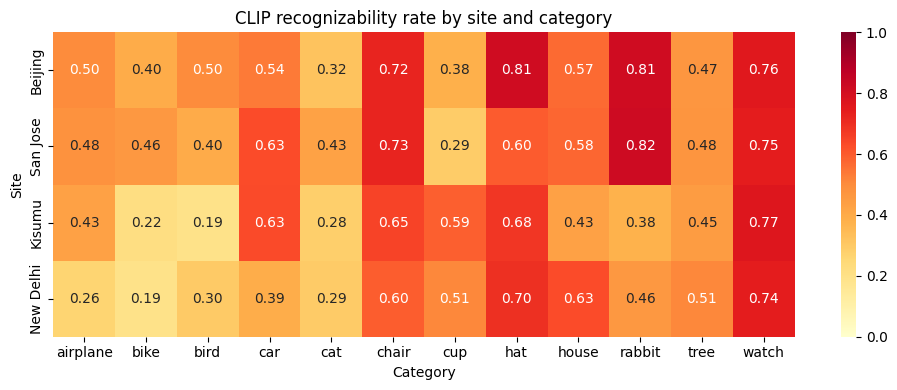

Recognizability by site:
location
Beijing      0.563536
San Jose     0.548883
Kisumu       0.475694
New Delhi    0.469144
Name: recognized, dtype: float64


In [24]:
# recognizability rates by site and category

recog_rates = (
    emb_df.groupby(['location', 'drawing_category'])['recognized']
    .mean()
    .unstack('drawing_category')
    .reindex(columns=CATEGORIES)
    .reindex(SITE_NAMES)
)

fig, ax = plt.subplots(figsize=(10, 4))
sns.heatmap(recog_rates, annot=True, fmt='.2f', cmap='YlOrRd', ax=ax, vmin=0, vmax=1)
ax.set(title='CLIP recognizability rate by site and category',
       xlabel='Category', ylabel='Site')
plt.tight_layout()
plt.savefig("../data/figures/eda_plots/recognizability_site_category.svg", dpi=150)
plt.show()

print("Recognizability by site:")
print(emb_df.groupby('location')['recognized'].mean().reindex(SITE_NAMES))

category recognizability vs RDM row similarity to other sites for Kisumu
r = -0.161, p = 0.6175


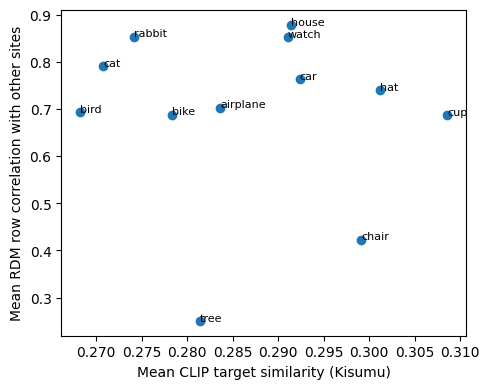

In [25]:
# category-level RDM row divergence vs continuous recognizability

def category_row_divergence(site_rdms, site_names, categories, target_site):
    """for each category, correlate its RDM row in target_site vs each other site."""
    other_sites = [s for s in site_names if s != target_site]
    rows = []
    for i, cat in enumerate(categories):
        target_row = np.delete(site_rdms[target_site][i], i)
        other_rows = [np.delete(site_rdms[s][i], i) for s in other_sites]
        mean_r = np.mean([spearmanr(target_row, r)[0] for r in other_rows])
        rows.append({'category': cat, 'mean_row_corr_with_others': mean_r})
    return pd.DataFrame(rows)

site_rdms_grouped = {
    loc: compute_rdm(emb_df[emb_df['location'] == loc], CATEGORIES_GROUPED)
    for loc in SITE_NAMES
}

kisumu_row_div = category_row_divergence(site_rdms_grouped, SITE_NAMES, CATEGORIES_GROUPED, 'Kisumu')

# continuous mean similarity per category at Kisumu
kisumu_mean_sim = (
    emb_df[emb_df['location'] == 'Kisumu']
    .groupby('drawing_category')['target_similarity']
    .mean()
    .reindex(CATEGORIES_GROUPED)
    .values
)
kisumu_row_div['mean_target_similarity'] = kisumu_mean_sim

r_val, p_val = spearmanr(kisumu_row_div['mean_target_similarity'],
                          kisumu_row_div['mean_row_corr_with_others'])
print(f"category recognizability vs RDM row similarity to other sites for Kisumu")
print(f"r = {r_val:.3f}, p = {p_val:.4f}")

fig, ax = plt.subplots(figsize=(5, 4))
ax.scatter(kisumu_row_div['mean_target_similarity'],
           kisumu_row_div['mean_row_corr_with_others'])
for _, row in kisumu_row_div.iterrows():
    ax.annotate(row['category'],
                (row['mean_target_similarity'], row['mean_row_corr_with_others']),
                fontsize=8, ha='left')
ax.set(xlabel='Mean CLIP target similarity (Kisumu)',
       ylabel='Mean RDM row correlation with other sites')
plt.tight_layout()
plt.savefig("../data/figures/eda_plots/kisumu_recog_vs_rdm_row.png", dpi=150)
plt.show()

In [26]:
# RDMs with matching target_similarity distributions across sites

def match_recognizability(emb_df, site_names, categories, n_bins=5, seed=42):
    """within each category, match target_similarity distributions across sites."""
    rng = np.random.default_rng(seed)
    matched_indices = []

    for cat in categories:
        cat_df = emb_df[emb_df['drawing_category'] == cat]
        bin_edges = np.quantile(cat_df['target_similarity'], np.linspace(0, 1, n_bins + 1))
        bin_edges[0] -= 1e-6
        cat_df = cat_df.copy()
        cat_df['sim_bin'] = pd.cut(cat_df['target_similarity'], bins=bin_edges, labels=False)

        for b in range(n_bins):
            bin_indices = {}
            for loc in site_names:
                idx = cat_df[(cat_df['location'] == loc) & (cat_df['sim_bin'] == b)].index
                bin_indices[loc] = idx

            min_count = min(len(idx) for idx in bin_indices.values())
            if min_count == 0:
                continue

            for loc in site_names:
                if len(bin_indices[loc]) > min_count:
                    kept = rng.choice(bin_indices[loc], size=min_count, replace=False)
                    matched_indices.extend(kept.tolist())
                else:
                    matched_indices.extend(bin_indices[loc].tolist())

    return emb_df.loc[matched_indices].copy()

matched_df = match_recognizability(emb_df, SITE_NAMES, CATEGORIES)

print("After matching:")
print(f"Total drawings: {len(matched_df)} (was {len(emb_df)})")
print("\nRecognizability by site (matched):")
print(matched_df.groupby('location')['recognized'].mean())
print("\nMean target similarity by site (matched):")
print(matched_df.groupby('location')['target_similarity'].mean())
print("\nDrawings per site-category cell:")
print(matched_df.groupby(['location', 'drawing_category']).size().unstack().to_string())

matched_rdms = {
    loc: compute_rdm(matched_df[matched_df['location'] == loc], CATEGORIES_GROUPED)
    for loc in SITE_NAMES
}

print("\nRDM correlations after recognizability matching:")
for s1, s2 in combinations(SITE_NAMES, 2):
    r_matched = spearman_rdm(matched_rdms[s1], matched_rdms[s2])
    r_orig = obs_corrs[(s1, s2)]
    print(f"{s1} vs {s2}: r = {r_matched:.3f} (was {r_orig:.3f})")

After matching:
Total drawings: 2392 (was 4387)

Recognizability by site (matched):
location
Beijing      0.560201
Kisumu       0.536789
New Delhi    0.540134
San Jose     0.536789
Name: recognized, dtype: float64

Mean target similarity by site (matched):
location
Beijing      0.290384
Kisumu       0.290305
New Delhi    0.289562
San Jose     0.290477
Name: target_similarity, dtype: float64

Drawings per site-category cell:
drawing_category  airplane  bike  bird  car  cat  chair  cup  hat  house  rabbit  tree  watch
location                                                                                     
Beijing                 51    47    49   52   53     46   45   49     61      35    57     53
Kisumu                  51    47    49   52   53     46   45   49     61      35    57     53
New Delhi               51    47    49   52   53     46   45   49     61      35    57     53
San Jose                51    47    49   52   53     46   45   49     61      35    57     53

RDM cor

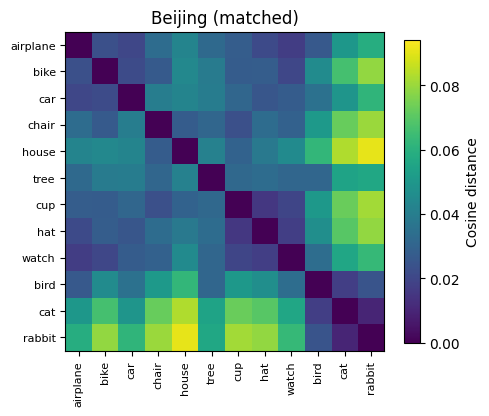

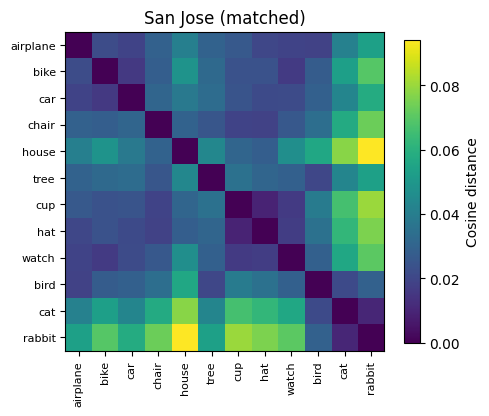

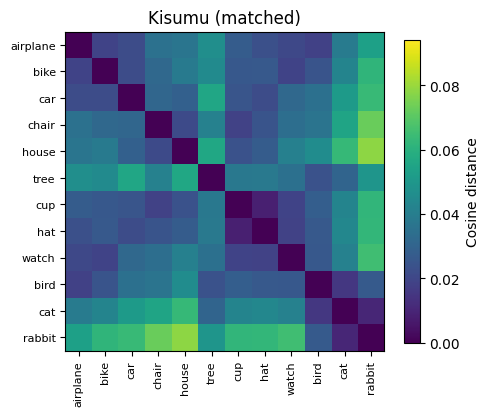

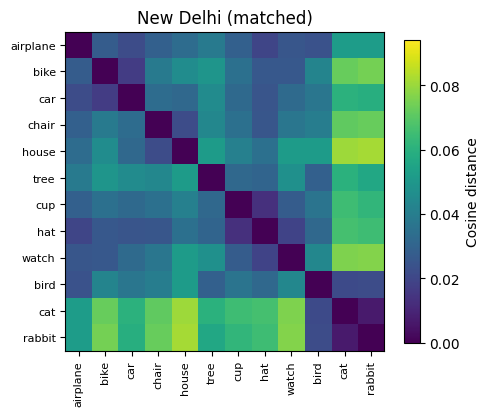

In [27]:
vmax = max(rdm[np.tril_indices(len(CATEGORIES_GROUPED), k=-1)].max()
            for rdm in matched_rdms.values())

for loc in SITE_NAMES:
    fig, ax = plt.subplots(figsize=(5, 4.5))
    im = ax.imshow(matched_rdms[loc], cmap='viridis', vmin=0, vmax=vmax)
    ax.set_xticks(range(len(CATEGORIES_GROUPED)))
    ax.set_yticks(range(len(CATEGORIES_GROUPED)))
    ax.set_xticklabels(CATEGORIES_GROUPED, rotation=90, fontsize=8)
    ax.set_yticklabels(CATEGORIES_GROUPED, fontsize=8)
    ax.set_title(f'{loc} (matched)')
    fig.colorbar(im, ax=ax, shrink=0.8, label='Cosine distance')
    plt.tight_layout()
    plt.savefig(f"../data/figures/rdm_plots/stats/rdm_matched_{loc.lower()}.svg", dpi=150, bbox_inches='tight')
    plt.show()

In [28]:
# control: random downsampling to same cell sizes, no similarity matching

matched_cell_sizes = matched_df.groupby(['location', 'drawing_category']).size()

def random_downsample(emb_df, target_cell_sizes, site_names, categories, n_iter=100, seed=42):
    rng = np.random.default_rng(seed)
    all_corrs = {pair: [] for pair in combinations(site_names, 2)}

    for _ in range(n_iter):
        sampled_indices = []
        for loc in site_names:
            for cat in categories:
                cell = emb_df[(emb_df['location'] == loc) & (emb_df['drawing_category'] == cat)]
                n_target = target_cell_sizes.get((loc, cat), 0)
                if n_target == 0 or len(cell) == 0:
                    continue
                n_target = min(n_target, len(cell))
                sampled = rng.choice(cell.index, size=n_target, replace=False)
                sampled_indices.extend(sampled.tolist())

        sampled_df = emb_df.loc[sampled_indices]
        sampled_rdms = {
            loc: compute_rdm(sampled_df[sampled_df['location'] == loc], CATEGORIES_GROUPED)
            for loc in site_names
        }
        for s1, s2 in combinations(site_names, 2):
            all_corrs[(s1, s2)].append(spearman_rdm(sampled_rdms[s1], sampled_rdms[s2]))

    return {pair: np.array(vals) for pair, vals in all_corrs.items()}

random_corrs = random_downsample(emb_df, matched_cell_sizes, SITE_NAMES, CATEGORIES)

print("Random downsample control (mean +/- sd over 100 iterations):")
for s1, s2 in combinations(SITE_NAMES, 2):
    rand_mean = random_corrs[(s1, s2)].mean()
    rand_sd = random_corrs[(s1, s2)].std()
    r_matched = spearman_rdm(matched_rdms[s1], matched_rdms[s2])
    r_orig = obs_corrs[(s1, s2)]
    print(f"{s1} vs {s2}: original = {r_orig:.3f}, matched = {r_matched:.3f}, "
          f"random = {rand_mean:.3f} (sd {rand_sd:.3f})")

Random downsample control (mean +/- sd over 100 iterations):
Beijing vs San Jose: original = 0.953, matched = 0.936, random = 0.947 (sd 0.010)
Beijing vs Kisumu: original = 0.725, matched = 0.857, random = 0.705 (sd 0.062)
Beijing vs New Delhi: original = 0.820, matched = 0.888, random = 0.800 (sd 0.054)
San Jose vs Kisumu: original = 0.777, matched = 0.889, random = 0.745 (sd 0.055)
San Jose vs New Delhi: original = 0.842, matched = 0.874, random = 0.821 (sd 0.051)
Kisumu vs New Delhi: original = 0.811, matched = 0.867, random = 0.771 (sd 0.052)


## Category divergence ranking (Analysis 2)

For each category, compute pairwise cosine distances between all 4 site centroids (6 pairs), then take the mean as the cross-site divergence score.


category  matched  original
  rabbit 0.010010  0.015381
     cat 0.009603  0.009847
    tree 0.009603  0.010010
     car 0.008789  0.009033
    bird 0.007324  0.009115
   chair 0.007324  0.005941
   house 0.007324  0.007487
     cup 0.006673  0.005941
     hat 0.006592  0.005615
airplane 0.005778  0.005615
   watch 0.005208  0.004395
    bike 0.004150  0.004801


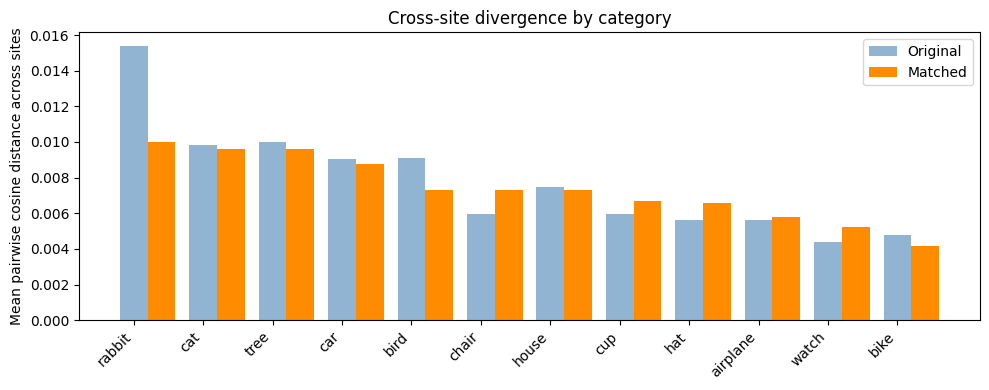

In [29]:

matched_centroids = {
    (loc, cat): np.mean(np.stack(grp['embedding'].values), axis=0)
    for (loc, cat), grp in matched_df.groupby(['location', 'drawing_category'])
}

divergence_rows = []
for cat in CATEGORIES:
    dists_matched = [
        1 - float(cosine_sim(matched_centroids[(s1, cat)], matched_centroids[(s2, cat)]))
        for s1, s2 in combinations(SITE_NAMES, 2)
    ]
    dists_orig = [
        1 - float(cosine_sim(centroids[(s1, cat)], centroids[(s2, cat)]))
        for s1, s2 in combinations(SITE_NAMES, 2)
    ]
    divergence_rows.append({
        'category': cat,
        'matched': np.mean(dists_matched),
        'original': np.mean(dists_orig),
    })

div_df = pd.DataFrame(divergence_rows).sort_values('matched', ascending=False).reset_index(drop=True)
print(div_df.to_string(index=False))

fig, ax = plt.subplots(figsize=(10, 4))
x = range(len(div_df))
ax.bar(x, div_df['original'], width=0.4, align='edge', label='Original', color='steelblue', alpha=0.6)
ax.bar([i + 0.4 for i in x], div_df['matched'], width=0.4, align='edge', label='Matched', color='darkorange')
ax.set_xticks([i + 0.2 for i in x])
ax.set_xticklabels(div_df['category'], rotation=45, ha='right')
ax.set(ylabel='Mean pairwise cosine distance across sites', title='Cross-site divergence by category')
ax.legend()
plt.tight_layout()
plt.savefig("../data/figures/eda_plots/category_divergence_comparison.svg", dpi=150)
plt.show()